In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from google.colab import files
from IPython.display import display

uploaded = files.upload()
filename = next(iter(uploaded))

#The other workbook sheets contain descriptions and a citation.
df = pd.read_excel(filename, sheet_name="SABER11_SABERPRO")

#Remove the completely empty columns
df = df.dropna(axis=1, how="all")

#Clean the categorical labels.
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

#These labels do not identify a known education level or stratum.
for col in ["EDU_FATHER", "EDU_MOTHER", "STRATUM"]:
    df[col] = df[col].replace({
        "0": np.nan,
        "Not sure": np.nan})

scores = [
    "MAT_S11", "CR_S11", "CC_S11", "BIO_S11", "ENG_S11",
    "QR_PRO", "CR_PRO", "CC_PRO", "ENG_PRO", "WC_PRO",
    "FEP_PRO", "G_SC"]

print("Dataset dimensions:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values after cleaning:")
display(df.isna().sum().loc[lambda x: x > 0])

print("\nOverall score summary:")
display(df[scores].describe().round(2))

Saving data_academic_performance.xlsx to data_academic_performance (1).xlsx
Dataset dimensions: (12411, 44)
Duplicate rows: 0

Missing values after cleaning:


,0
EDU_FATHER,798
EDU_MOTHER,567
OCC_FATHER,940
OCC_MOTHER,313
STRATUM,14
SISBEN,21
PEOPLE_HOUSE,21
REVENUE,279
JOB,138



Overall score summary:


,MAT_S11,CR_S11,CC_S11,BIO_S11,ENG_S11,QR_PRO,CR_PRO,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC
count,12411.00,12411.00,12411.00,12411.00,12411.0,12411.00,12411.00,12411.00,12411.0,12411.0,12411.00,12411.00
mean,64.32,60.78,60.71,63.95,61.8,77.42,62.20,59.19,67.5,53.7,145.48,162.71
std,11.87,10.03,10.12,11.16,14.3,22.67,27.67,28.99,25.5,30.0,40.13,23.11
min,26.00,24.00,0.00,11.00,26.0,1.00,1.00,1.00,1.0,0.0,1.00,37.00
25%,56.00,54.00,54.00,56.00,50.0,65.00,42.00,36.00,51.0,28.0,124.00,147.00
50%,64.00,61.00,60.00,64.00,59.0,85.00,67.00,65.00,74.0,56.0,153.00,163.00
75%,72.00,67.00,67.00,71.00,72.0,96.00,86.00,85.00,88.0,80.0,174.00,179.00
max,100.00,100.00,100.00,100.00,100.0,100.00,100.00,100.00,100.0,100.0,300.00,247.00


In [3]:
#Summarize the numerical scores by category
categories = [
    "EDU_FATHER", "EDU_MOTHER", "STRATUM",
    "GENDER", "ACADEMIC_PROGRAM"]

for category in categories:
    print(f"\nScores grouped by {category}")
    summary = df.groupby(category)[scores].agg(["count", "mean", "std"])
    display(summary.round(2))


Scores grouped by EDU_FATHER


MAT_S11               CR_S11         \
                                        count   mean    std  count   mean   
EDU_FATHER                                                                  
Complete Secundary                       2843  62.28  11.28   2843  59.43   
Complete primary                          824  60.66  10.91    824  57.98   
Complete professional education          3016  67.01  11.94   3016  62.49   
Complete technique or technology         1194  64.88  11.61   1194  61.29   
Incomplete Professional Education         425  66.27  11.35    425  62.38   
Incomplete Secundary                     1091  61.27  10.64   1091  58.71   
Incomplete primary                        735  61.25  10.99    735  58.52   
Incomplete technical or technological     277  63.39  10.77    277  60.61   
Ninguno                                   123  60.71  11.47    123  58.27   
Postgraduate education                   1085  71.91  11.88   1085  65.88   

                                            CC_S11               BIO_S11  ...  \
                                        std  count   mean    std   count  ...   
EDU_FATHER                                                                ...   
Complete Secundary                     9.93   2843  59.30   9.67    2843  ...   
Complete primary                       9.53    824  58.55  10.01     824  ...   
Complete professional education        9.85   3016  62.37   9.97    3016  ...   
Complete technique or technology       9.54   1194  61.27   9.77    1194  ...   
Incomplete Professional Education      9.42    425  62.16   9.65     425  ...   
Incomplete Secundary                   9.97   1091  58.66  10.05    1091  ...   
Incomplete primary                     9.82    735  58.78  10.28     735  ...   
Incomplete technical or technological  9.63    277  59.99  10.53     277  ...   
Ninguno                                9.53    123  58.24   9.54     123  ...   
Postgraduate education                 9.49   1085  65.50   9.96    1085  ...   

                                      ENG_PRO WC_PRO               FEP_PRO  \
                                          std  count   mean    std   count   
EDU_FATHER                                                                   
Complete Secundary                      25.79   2843  51.26  29.30    2843   
Complete primary                        25.49    824  49.97  29.77     824   
Complete professional education         23.24   3016  56.03  30.18    3016   
Complete technique or technology        22.92   1194  53.87  30.07    1194   
Incomplete Professional Education       21.97    425  55.36  31.18     425   
Incomplete Secundary                    24.79   1091  51.38  29.78    1091   
Incomplete primary                      26.47    735  51.14  29.36     735   
Incomplete technical or technological   25.88    277  53.89  30.85     277   
Ninguno                                 27.17    123  49.76  30.90     123   
Postgraduate education                  18.24   1085  62.31  29.27    1085   

                                                      G_SC                 
                                         mean    std count    mean    std  
EDU_FATHER                                                                 
Complete Secundary                     142.48  39.17  2843  158.79  22.11  
Complete primary                       139.99  37.88   824  155.20  22.41  
Complete professional education        149.50  39.96  3016  167.77  23.03  
Complete technique or technology       146.39  41.43  1194  164.03  22.17  
Incomplete Professional Education      146.98  44.07   425  166.92  22.69  
Incomplete Secundary                   140.22  39.57  1091  156.54  21.74  
Incomplete primary                     140.99  38.98   735  155.73  20.94  
Incomplete technical or technological  143.74  38.31   277  162.10  21.88  
Ninguno                                148.59  35.63   123  156.63  23.19  
Postgraduate education                 155.90  41.02  1


Scores grouped by EDU_MOTHER


MAT_S11               CR_S11         \
                                        count   mean    std  count   mean   
EDU_MOTHER                                                                  
Complete Secundary                       3106  62.19  11.04   3106  59.24   
Complete primary                          713  60.50  11.20    713  57.77   
Complete professional education          3059  67.44  12.17   3059  62.78   
Complete technique or technology         1495  64.56  11.76   1495  61.27   
Incomplete Professional Education         502  65.99  11.27    502  62.80   
Incomplete Secundary                     1056  60.95  10.42   1056  58.34   
Incomplete primary                        541  60.82  11.36    541  58.23   
Incomplete technical or technological     341  64.04  10.92    341  61.49   
Ninguno                                    34  63.50  12.10     34  57.26   
Postgraduate education                    997  70.93  11.66    997  65.21   

                                             CC_S11               BIO_S11  \
                                         std  count   mean    std   count   
EDU_MOTHER                                                                  
Complete Secundary                      9.79   3106  59.32   9.78    3106   
Complete primary                        9.70    713  58.40   9.74     713   
Complete professional education         9.90   3059  62.58  10.12    3059   
Complete technique or technology        9.96   1495  61.20   9.99    1495   
Incomplete Professional Education       9.31    502  62.26   9.70     502   
Incomplete Secundary                    9.45   1056  58.52   9.68    1056   
Incomplete primary                      9.65    541  58.26  10.23     541   
Incomplete technical or technological   9.54    341  60.76   9.72     341   
Ninguno                                10.88     34  57.06  10.15      34   
Postgraduate education                  9.70    997  64.81   9.88     997   

                                       ... ENG_PRO WC_PRO                \
                                       ...     std  count   mean    std   
EDU_MOTHER                             ...                                
Complete Secundary                     ...   25.36   3106  51.24  29.35   
Complete primary                       ...   25.80    713  49.83  29.76   
Complete professional education        ...   22.63   3059  57.16  30.00   
Complete technique or technology       ...   24.09   1495  53.05  30.44   
Incomplete Professional Education      ...   22.56    502  55.62  30.59   
Incomplete Secundary                   ...   25.15   1056  49.84  29.64   
Incomplete primary                     ...   26.60    541  51.29  30.02   
Incomplete technical or technological  ...   23.55    341  52.26  29.44   
Ninguno                                ...   29.27     34  41.79  29.79   
Postgraduate education                 ...   20.32    997  62.03  29.53   

                                      FEP_PRO                 G_SC          \
                                        count    mean    std count    mean   
EDU_MOTHER                                                                   
Complete Secundary                       3106  141.97  39.10  3106  158.47   
Complete primary                          713  141.35  39.16   713  155.34   
Complete professional education          3059  149.93  41.18  3059  168.85   
Complete technique or technology         1495  146.41  40.94  1495  163.24   
Incomplete Professional Education         502  146.28  40.35   502  166.69   
Incomplete Secundary                     1056  140.87  38.21  1056  155.67   
Incomplete primary                        541  141.76  37.40   541  154.85   
Incomplete technical or technological     341  144.11  39.13   341  161.88   
Ninguno                                    34  147.06  32.54    34  149.71   
Postgraduate education                    997  154.98  39.98   997  175.64   

                                           


Scores grouped by STRATUM


MAT_S11               CR_S11              CC_S11                \
            count   mean    std  count   mean   std  count   mean    std   
STRATUM                                                                    
Stratum 1    1709  59.85  11.06   1709  57.08  9.90   1709  57.27   9.66   
Stratum 2    4029  62.08  11.09   4029  59.12  9.73   4029  59.21   9.82   
Stratum 3    4045  64.34  11.21   4045  61.48  9.82   4045  61.30   9.91   
Stratum 4    1578  69.11  11.81   1578  64.06  9.46   1578  63.58   9.83   
Stratum 5     633  72.13  11.83    633  65.49  9.39    633  64.88   9.85   
Stratum 6     403  74.67  11.63    403  66.01  8.85    403  66.67  10.20   

          BIO_S11  ... ENG_PRO WC_PRO               FEP_PRO                 \
            count  ...     std  count   mean    std   count    mean    std   
STRATUM            ...                                                       
Stratum 1    1709  ...   26.21   1709  49.30  29.58    1709  142.98  35.26   
Stratum 2    4029  ...   25.14   4029  51.15  29.60    4029  142.48  38.99   
Stratum 3    4045  ...   22.65   4045  53.04  30.20    4045  142.20  43.04   
Stratum 4    1578  ...   19.75   1578  59.59  29.35    1578  154.05  39.87   
Stratum 5     633  ...   16.59    633  63.66  29.04     633  160.42  34.86   
Stratum 6     403  ...   10.95    403  65.59  28.21     403  162.17  35.36   

           G_SC                 
          count    mean    std  
STRATUM                         
Stratum 1  1709  152.35  21.94  
Stratum 2  4029  158.20  22.28  
Stratum 3  4045  163.82  21.69  
Stratum 4  1578  172.00  21.47  
Stratum 5   633  177.39  21.54  
Stratum 6   403  181.51  21.88  

[6 rows x 36 columns]


Scores grouped by GENDER


MAT_S11               CR_S11              CC_S11               BIO_S11  \
         count   mean    std  count  mean    std  count   mean    std   count   
GENDER                                                                          
F         5043  61.93  11.17   5043  60.9   9.87   5043  59.96   9.52    5043   
M         7368  65.96  12.06   7368  60.7  10.13   7368  61.22  10.48    7368   

        ... ENG_PRO WC_PRO               FEP_PRO                G_SC          \
        ...     std  count   mean    std   count   mean    std count    mean   
GENDER  ...                                                                    
F       ...   24.76   5043  56.62  29.23    5043  145.3  39.30  5043  161.28   
M       ...   25.97   7368  51.71  30.36    7368  145.6  40.69  7368  163.69   

               
          std  
GENDER         
F       22.33  
M       23.58  

[2 rows x 36 columns]


Scores grouped by ACADEMIC_PROGRAM


MAT_S11               CR_S11  \
                                                count   mean    std  count   
ACADEMIC_PROGRAM                                                             
AERONAUTICAL ENGINEERING                           44  59.98   9.08     44   
AUTOMATION ENGINEERING                             10  68.70   8.65     10   
CATASTRAL ENGINEERING AND GEODESY                  78  69.23   7.52     78   
CHEMICAL ENGINEERING                             1000  69.38  10.45   1000   
CIVIL CONSTRUCTIONS                                14  53.71   8.92     14   
CIVIL ENGINEERING                                3320  64.01  11.83   3320   
CONTROL ENGINEERING                                20  72.95  10.62     20   
ELECTRIC ENGINEERING                              278  71.77  11.48    278   
ELECTRIC ENGINEERING AND TELECOMMUNICATIONS        47  62.38   9.58     47   
ELECTROMECHANICAL ENGINEERING                      34  61.26  10.30     34   
ELECTRONIC ENGINEERING                            849  67.89  12.04    849   
INDUSTRIAL AUTOMATIC ENGINEERING                   22  64.59   9.02     22   
INDUSTRIAL CONTROL AND AUTOMATION ENGINEERING       1  45.00    NaN      1   
INDUSTRIAL ENGINEERING                           5318  61.88  11.43   5318   
MECHANICAL ENGINEERING                           1135  67.66  12.42   1135   
MECHATRONICS ENGINEERING                           82  60.50   9.31     82   
PRODUCTION ENGINEERING                             60  67.27  11.80     60   
PRODUCTIVITY AND QUALITY ENGINEERING               29  60.55   7.43     29   
TEXTILE ENGINEERING                                 1  59.00    NaN      1   
TOPOGRAPHIC ENGINEERY                              42  68.33   6.91     42   
TRANSPORTATION AND ROAD ENGINEERING                27  67.74   6.27     27   

                                                            CC_S11         \
                                                mean    std  count   mean   
ACADEMIC_PROGRAM                                                            
AERONAUTICAL ENGINEERING                       57.75   6.38     44  58.45   
AUTOMATION ENGINEERING                         63.80   9.19     10  59.80   
CATASTRAL ENGINEERING AND GEODESY              68.71   7.23     78  68.62   
CHEMICAL ENGINEERING                           65.48   8.91   1000  65.58   
CIVIL CONSTRUCTIONS                            56.71   4.32     14  57.43   
CIVIL ENGINEERING                              59.85   9.94   3320  60.04   
CONTROL ENGINEERING                            65.90   8.68     20  65.20   
ELECTRIC ENGINEERING                           66.19   9.93    278  65.95   
ELECTRIC ENGINEERING AND TELECOMMUNICATIONS    60.28   7.46     47  59.83   
ELECTROMECHANICAL ENGINEERING                  58.29  11.23     34  59.47   
ELECTRONIC ENGINEERING                         62.81  10.19    849  63.24   
INDUSTRIAL AUTOMATIC ENGINEERING               62.18   9.59     22  61.18   
INDUSTRIAL CONTROL AND AUTOMATION ENGINEERING  43.00    NaN      1  44.00   
INDUSTRIAL ENGINEERING                         59.52   9.79   5318  59.14   
MECHANICAL ENGINEERING                         62.07  10.41   1135  62.20   
MECHATRONICS ENGINEERING                       54.82   8.85     82  56.00   
PRODUCTION ENGINEERING                         63.78   9.42     60  63.35   
PRODUCTIVITY AND QUALITY ENGINEERING           61.55   9.49     29  61.00   
TEXTILE ENGINEERING                            62.00    NaN      1  67.00   
TOPOGRAPHIC ENGINEERY                          64.14   7.26     42  63.98   
TRANSPORTATION AND ROAD ENGINEERING            62.63   7.28     27  58.89   

                                                     BIO_S11  ... ENG_PRO  \
                                                 std   count  ...     std   
ACADEMIC_PROGRAM                                              ...           
AERONAUTICAL ENGINEERING                        8.27      44  ...   20.82   
AUTOMATION ENGIN

In [4]:
#Compare parental education and strata
def compare_groups(category):
    data = df.dropna(subset=[category, "G_SC"])

    table = data.groupby(category)["G_SC"].agg(
        n="count",
        mean="mean",
        sd="std")

    groups = [
        group["G_SC"].to_numpy()
        for _, group in data.groupby(category)]

    f_stat, p_value = stats.f_oneway(*groups)

    overall_mean = data["G_SC"].mean()
    between_ss = sum(
        len(group) * (group.mean() - overall_mean) ** 2
        for group in groups)
    total_ss = ((data["G_SC"] - overall_mean) ** 2).sum()
    eta_squared = between_ss / total_ss

    print(f"\n{category}")
    display(table.round(2))
    print(f"F = {f_stat:.2f}")
    print(f"p = {p_value:.3e}")
    print(f"Eta squared = {eta_squared:.4f}")

    return table
father_table = compare_groups("EDU_FATHER")
mother_table = compare_groups("EDU_MOTHER")
stratum_table = compare_groups("STRATUM")


EDU_FATHER


,n,mean,sd
EDU_FATHER,,,
Complete Secundary,2843,158.79,22.11
Complete primary,824,155.20,22.41
Complete professional education,3016,167.77,23.03
Complete technique or technology,1194,164.03,22.17
Incomplete Professional Education,425,166.92,22.69
Incomplete Secundary,1091,156.54,21.74
Incomplete primary,735,155.73,20.94
Incomplete technical or technological,277,162.10,21.88
Ninguno,123,156.63,23.19


F = 107.30
p = 6.158e-194
Eta squared = 0.0768

EDU_MOTHER


,n,mean,sd
EDU_MOTHER,,,
Complete Secundary,3106,158.47,21.95
Complete primary,713,155.34,22.01
Complete professional education,3059,168.85,22.98
Complete technique or technology,1495,163.24,21.94
Incomplete Professional Education,502,166.69,22.93
Incomplete Secundary,1056,155.67,21.93
Incomplete primary,541,154.85,21.64
Incomplete technical or technological,341,161.88,20.74
Ninguno,34,149.71,27.93


F = 106.68
p = 5.530e-193
Eta squared = 0.0750

STRATUM


,n,mean,sd
STRATUM,,,
Stratum 1,1709,152.35,21.94
Stratum 2,4029,158.20,22.28
Stratum 3,4045,163.82,21.69
Stratum 4,1578,172.00,21.47
Stratum 5,633,177.39,21.54
Stratum 6,403,181.51,21.88


F = 286.06
p = 1.426e-290
Eta squared = 0.1035


In [5]:
#Compare genders
gender_table = df.groupby("GENDER")["G_SC"].agg(
    n="count",
    mean="mean",
    sd="std")

display(gender_table.round(2))

male = df.loc[df["GENDER"] == "M", "G_SC"].dropna()
female = df.loc[df["GENDER"] == "F", "G_SC"].dropna()

# Welch's t-test allows unequal group variances.
t_stat, p_value = stats.ttest_ind(male, female, equal_var=False)

difference = male.mean() - female.mean()

pooled_sd = np.sqrt(
    ((len(male) - 1) * male.var()
     + (len(female) - 1) * female.var())
    / (len(male) + len(female) - 2))
cohens_d = difference / pooled_sd

print(f"Male minus female mean: {difference:.2f} points")
print(f"Welch t = {t_stat:.2f}")
print(f"p = {p_value:.3e}")
print(f"Cohen's d = {cohens_d:.3f}")

print("\nProfessional assessment scores by gender:")
display(
    df.groupby("GENDER")[
        ["QR_PRO", "CR_PRO", "CC_PRO", "ENG_PRO", "WC_PRO"]
    ].mean().round(2))

,n,mean,sd
GENDER,,,
F,5043,161.28,22.33
M,7368,163.69,23.58


Male minus female mean: 2.41 points
Welch t = 5.78
p = 7.785e-09
Cohen's d = 0.105

Professional assessment scores by gender:


,QR_PRO,CR_PRO,CC_PRO,ENG_PRO,WC_PRO
GENDER,,,,,
F,71.89,61.34,58.57,66.53,56.62
M,81.20,62.79,59.61,68.16,51.71


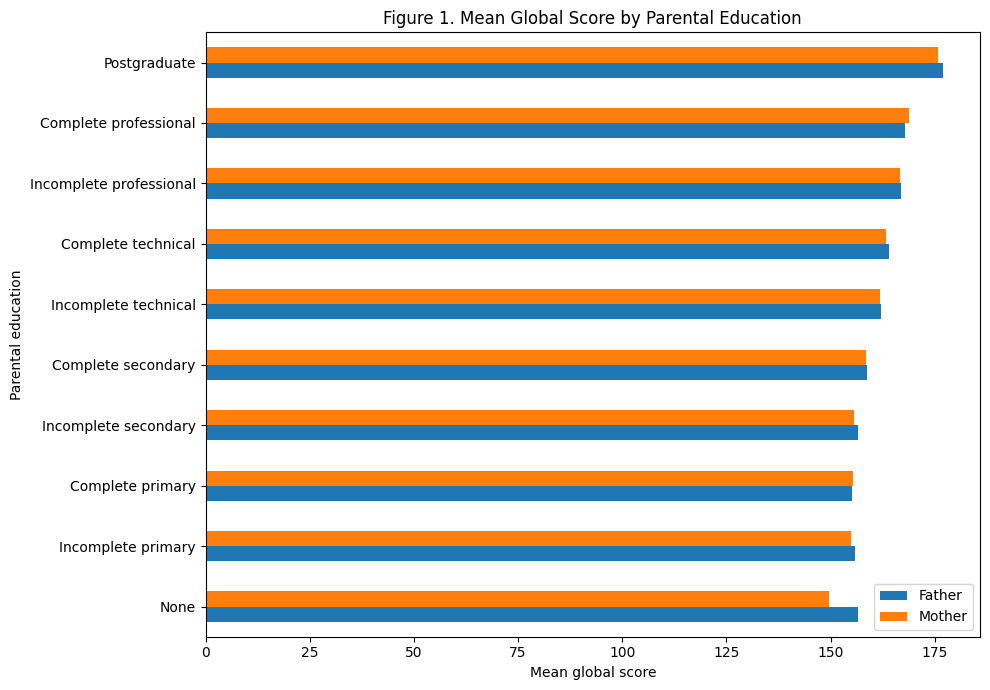

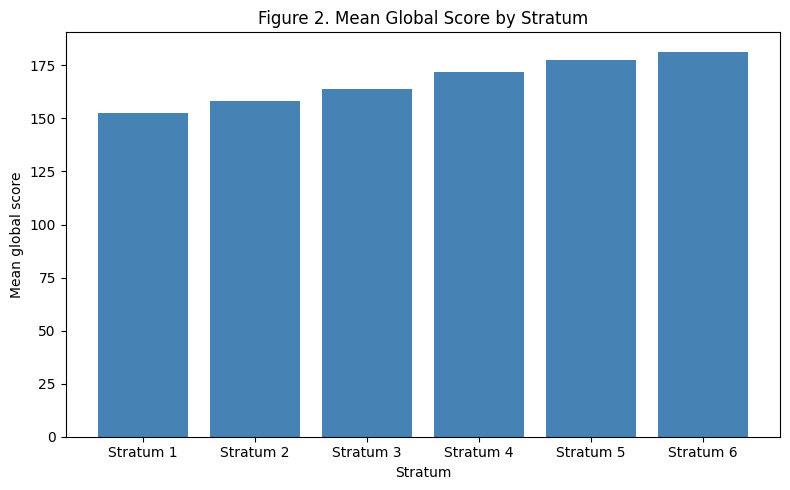

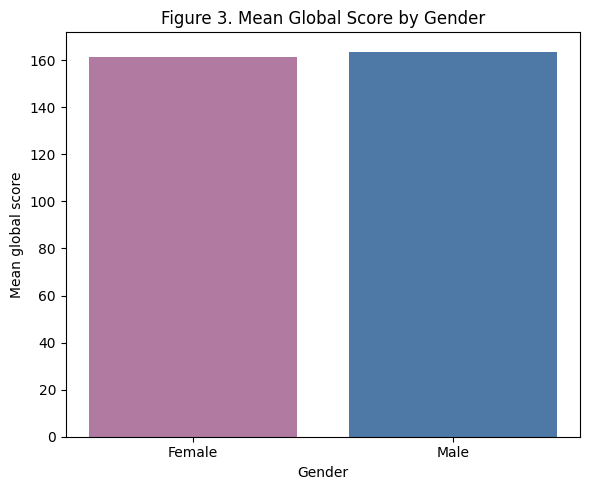

In [6]:
#Create figures for the report
education_order = [
    "Ninguno",
    "Incomplete primary",
    "Complete primary",
    "Incomplete Secundary",
    "Complete Secundary",
    "Incomplete technical or technological",
    "Complete technique or technology",
    "Incomplete Professional Education",
    "Complete professional education",
    "Postgraduate education"]

education_labels = [
    "None", "Incomplete primary", "Complete primary",
    "Incomplete secondary", "Complete secondary",
    "Incomplete technical", "Complete technical",
    "Incomplete professional", "Complete professional",
    "Postgraduate"]

# Figure 1
parent_means = pd.DataFrame({
    "Father": father_table["mean"],
    "Mother": mother_table["mean"]
}).reindex(education_order)

ax = parent_means.plot.barh(figsize=(10, 7))
ax.set_yticklabels(education_labels)
ax.set_xlabel("Mean global score")
ax.set_ylabel("Parental education")
ax.set_title("Figure 1. Mean Global Score by Parental Education")
plt.tight_layout()
plt.show()

# Figure 2
stratum_order = [f"Stratum {i}" for i in range(1, 7)]

plt.figure(figsize=(8, 5))
plt.bar(
    stratum_order,
    stratum_table.reindex(stratum_order)["mean"],
    color="steelblue")
plt.xlabel("Stratum")
plt.ylabel("Mean global score")
plt.title("Figure 2. Mean Global Score by Stratum")
plt.tight_layout()
plt.show()

# Figure 3
plt.figure(figsize=(6, 5))
plt.bar(
    ["Female", "Male"],
    gender_table.reindex(["F", "M"])["mean"],
    color=["#B07AA1", "#4E79A7"])
plt.xlabel("Gender")
plt.ylabel("Mean global score")
plt.title("Figure 3. Mean Global Score by Gender")
plt.tight_layout()
plt.show()